In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib 

In [51]:
df = pd.read_csv("Dataset.csv")
df.shape

(7043, 21)

In [52]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# DATA CLEANING / BASIC ANALYSIS 

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [55]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [56]:
df.drop('customerID', axis=1, inplace = True)

In [57]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(22)

In [59]:
df.drop_duplicates(inplace=True)

In [60]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [61]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [62]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [63]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [64]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn
['No' 'Yes']


In [65]:
df.replace({
    "No internet service": "No",
    "No phone service": "No"
}, inplace=True)

# EDA

In [66]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Cat Features:", cat_cols)
print("Num Features:", num_cols)

Cat Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Num Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [67]:
df.shape

(7021, 20)

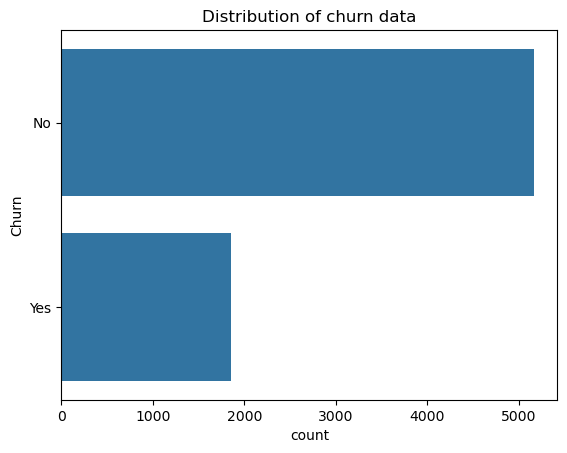

In [68]:
sns.countplot(df["Churn"])
plt.title("Distribution of churn data")
plt.show()

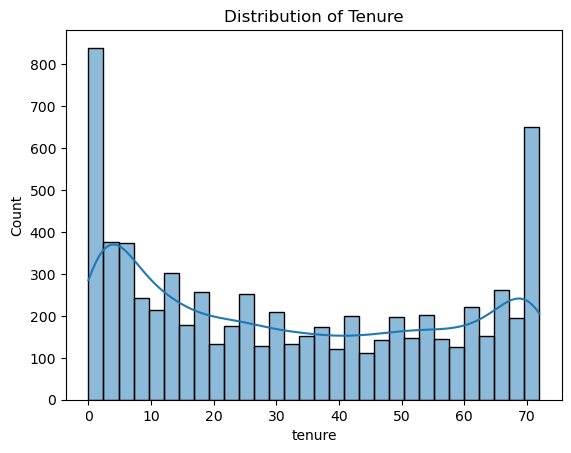

In [69]:
sns.histplot(df["tenure"], kde=True, bins=30)
plt.title("Distribution of Tenure")
plt.show()

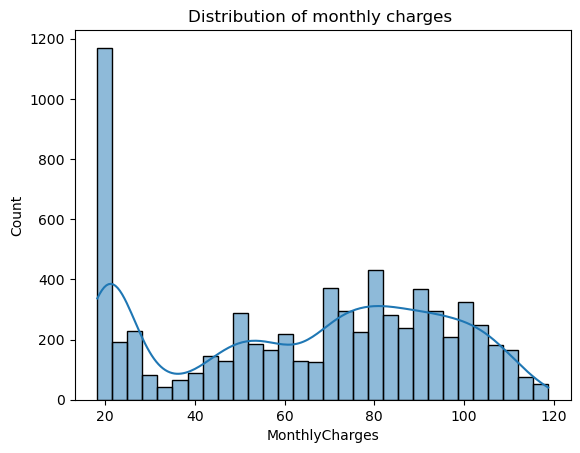

In [70]:
sns.histplot(df["MonthlyCharges"], kde=True, bins=30)
plt.title("Distribution of monthly charges ")
plt.show()

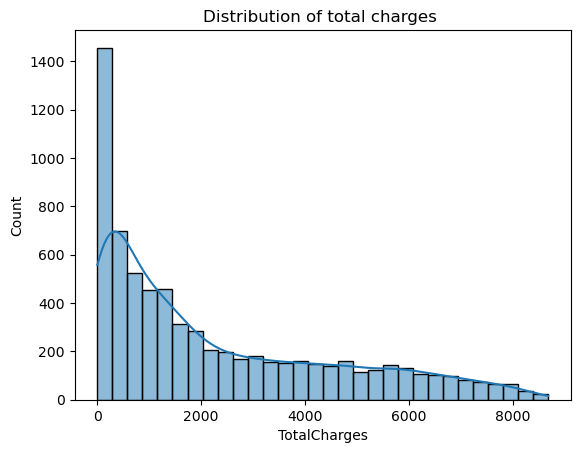

In [71]:
sns.histplot(df["TotalCharges"], kde=True, bins=30)
plt.title("Distribution of total charges ")
plt.show()

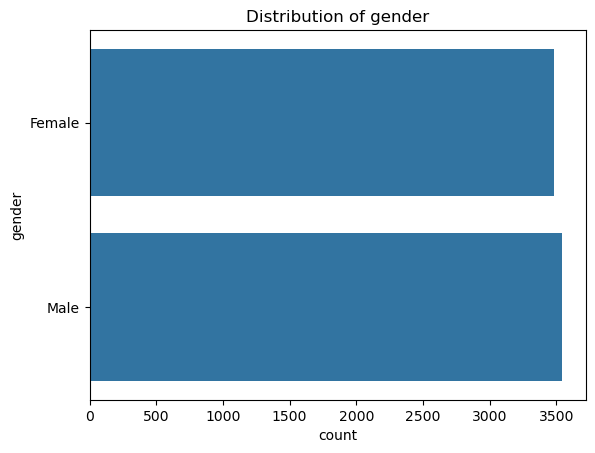

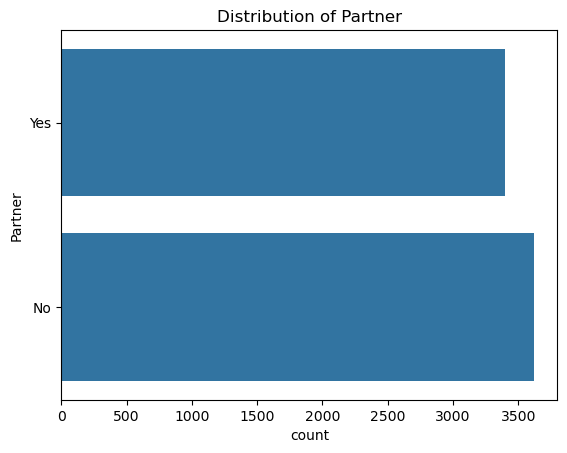

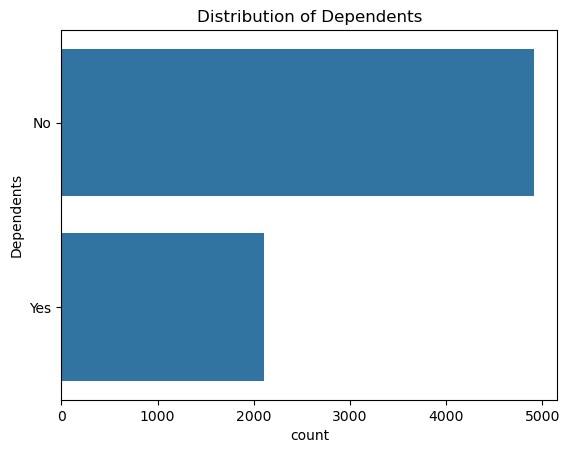

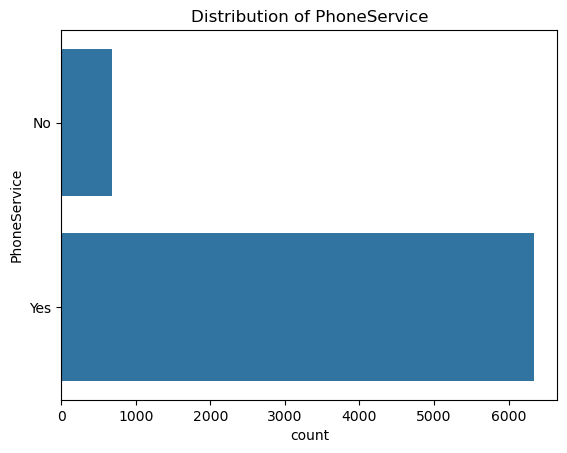

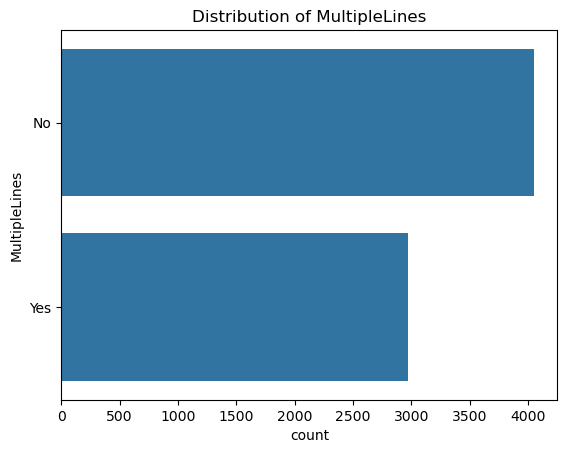

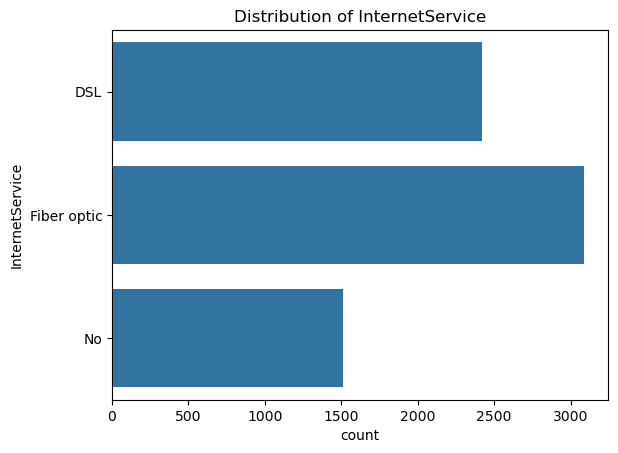

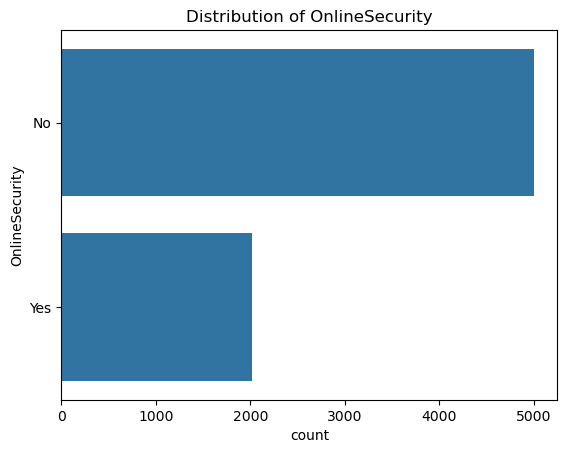

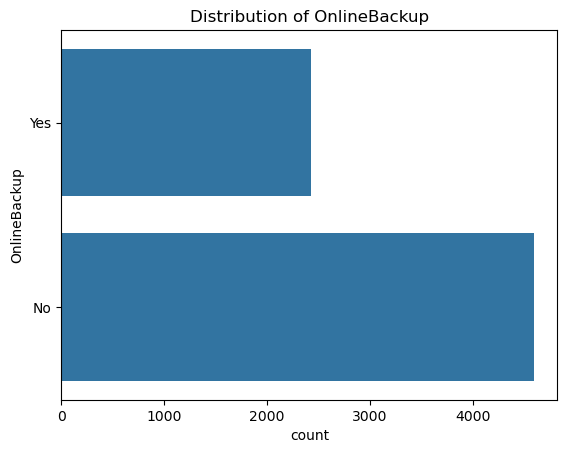

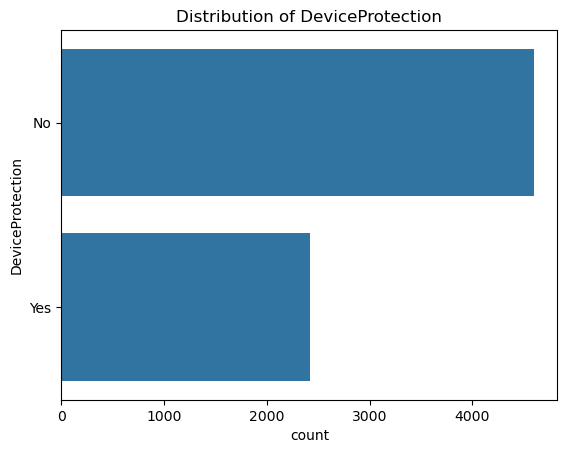

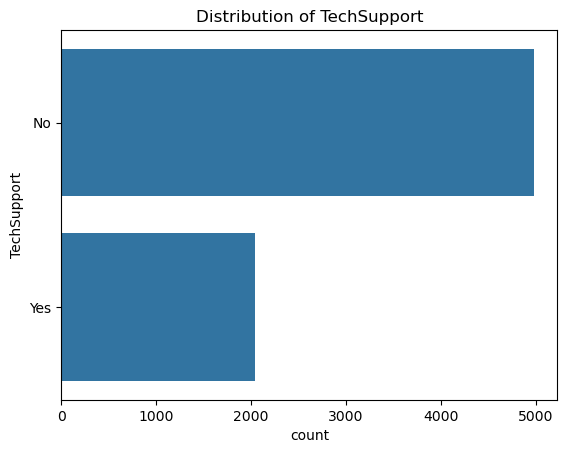

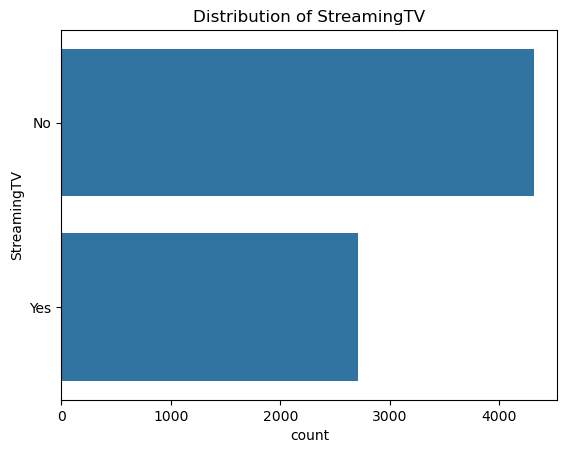

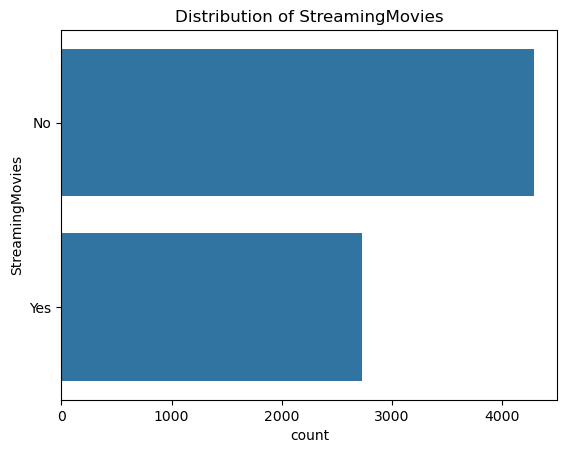

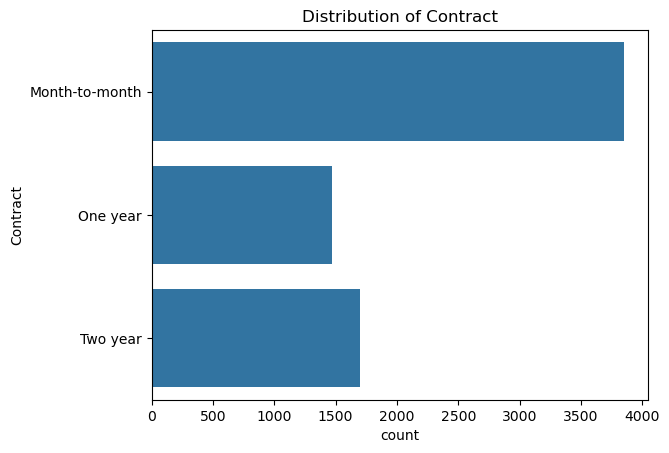

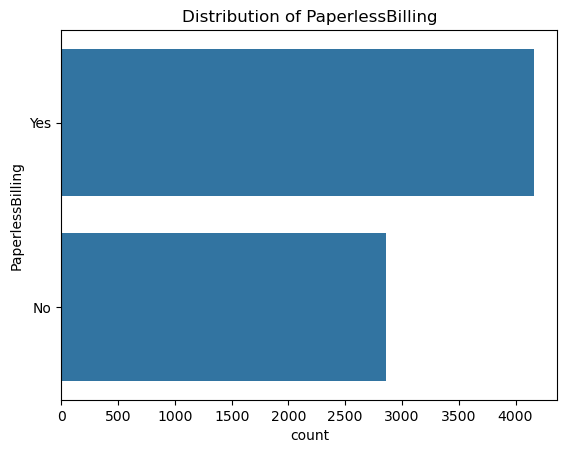

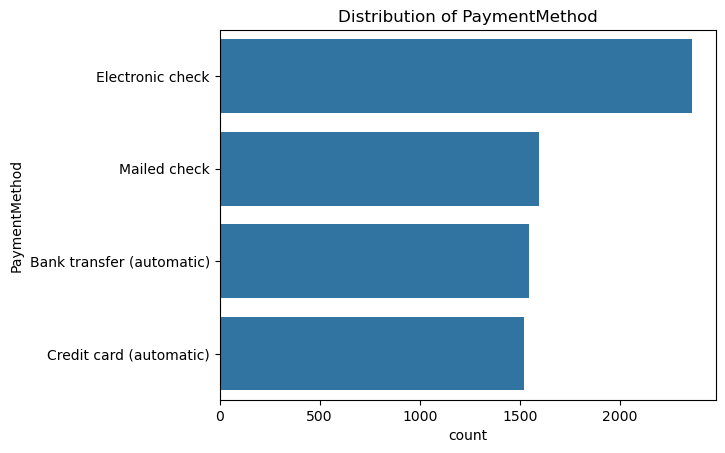

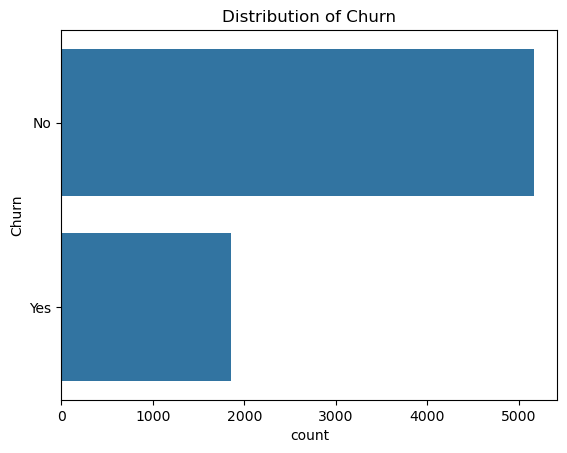

In [72]:
for col in cat_cols:
    sns.countplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

In [73]:
numeric_df = df.select_dtypes(include=np.number)
corr_mat = numeric_df.corr()
print(corr_mat)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.015349        0.219434      0.102243
tenure               0.015349  1.000000        0.245251      0.825595
MonthlyCharges       0.219434  0.245251        1.000000      0.650653
TotalCharges         0.102243  0.825595        0.650653      1.000000


<Axes: >

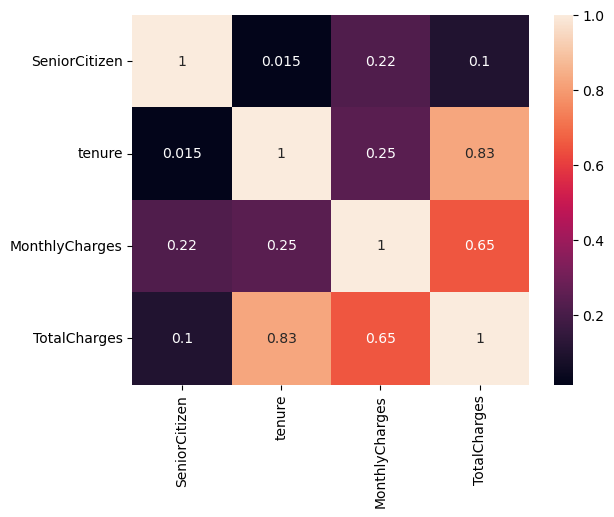

In [74]:
sns.heatmap(corr_mat,annot=True)

# Feature Engineering

In [75]:
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

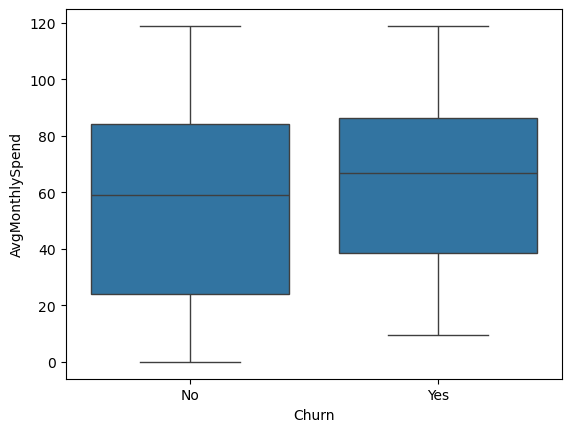

In [76]:
sns.boxplot(data=df, x="Churn", y="AvgMonthlySpend")
plt.show()

# Preprocessing 

In [77]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [78]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [79]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)
joblib.dump(target_encoder,"target_encoder.pkl")

['target_encoder.pkl']

In [80]:
categorical_cols = X.select_dtypes(include=["object"]).columns

ohe = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoded = ohe.fit_transform(X[categorical_cols])

In [81]:
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X.index
)
X = X.drop(columns=categorical_cols)
X = pd.concat([X, encoded_df], axis=1)

joblib.dump(ohe, "onehot_encoder.pkl")

['onehot_encoder.pkl']

In [82]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [127]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

# Training Different Models

In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

In [129]:
# LOGISTIC REGRESSION 
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [130]:
y_pred = lr.predict(X_test_scaled)

print("accuracy = ",accuracy_score(y_test,y_pred))

accuracy =  0.7943060498220641


In [131]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [132]:
best_lr = grid_lr.best_estimator_

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
0.6017075939797345


In [133]:
y_pred_lr = best_lr.predict(X_test_scaled)

In [134]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1053
           1       0.60      0.57      0.58       352

    accuracy                           0.80      1405
   macro avg       0.73      0.72      0.72      1405
weighted avg       0.79      0.80      0.80      1405



In [135]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print(accuracy, precision, recall, f1)

0.797153024911032 0.6012084592145015 0.5653409090909091 0.582723279648609


In [136]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[921 132]
 [153 199]]


In [137]:
lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Best Parameters": grid_lr.best_params_,
    "Confusion Matrix": cm
}

In [138]:
# KNNC
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [139]:
y_pred = knn.predict(X_test_scaled)

print("accuracy = ",accuracy_score(y_test,y_pred))

accuracy =  0.7466192170818505


In [140]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [141]:
best_knn = grid_knn.best_estimator_

print(grid_knn.best_params_)
print(grid_knn.best_score_)

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
0.5756655938039972


In [142]:
y_pred_knn = best_knn.predict(X_test_scaled)

In [143]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1053
           1       0.56      0.56      0.56       352

    accuracy                           0.78      1405
   macro avg       0.71      0.71      0.71      1405
weighted avg       0.78      0.78      0.78      1405



In [144]:
knn_results = {
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn),
    "Best Parameters": grid_knn.best_params_,
    "Confusion Matrix": confusion_matrix(y_test, y_pred_knn)
}

In [145]:
# DTC
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [146]:
y_pred = dt.predict(X_test)
print("accuracy = ",accuracy_score(y_test,y_pred))

accuracy =  0.7316725978647687


In [147]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [148]:
best_dt = grid_dt.best_estimator_

print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.5546577747895725


In [149]:
y_pred_dt = best_dt.predict(X_test)

In [150]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1053
           1       0.58      0.49      0.53       352

    accuracy                           0.78      1405
   macro avg       0.71      0.69      0.70      1405
weighted avg       0.77      0.78      0.78      1405



In [151]:
dt_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt),
    "Best Parameters": grid_dt.best_params_,
    "Confusion Matrix": confusion_matrix(y_test, y_pred_dt)
}

In [152]:
# RANDOM FOREST 
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [153]:
y_pred = rf.predict(X_test)
print("accuracy = ",accuracy_score(y_test,y_pred))

accuracy =  0.795017793594306


In [154]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ["gini", "entropy"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [155]:
best_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
0.5827667396493006


In [156]:
y_pred_rf = best_rf.predict(X_test)

In [157]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1053
           1       0.63      0.51      0.57       352

    accuracy                           0.80      1405
   macro avg       0.74      0.71      0.72      1405
weighted avg       0.79      0.80      0.80      1405



In [158]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "Best Parameters": grid_rf.best_params_,
    "Confusion Matrix": confusion_matrix(y_test, y_pred_rf)
}

# COMPARISON 

In [159]:
comparison_df = pd.DataFrame([
    lr_results,
    knn_results,
    dt_results,
    rf_results
])

comparison_df = comparison_df.drop(columns=["Best Parameters", "Confusion Matrix"])

comparison_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.797153,0.601208,0.565341,0.582723
3,Random Forest,0.802847,0.630662,0.514205,0.566510
1,KNN,0.779359,0.560000,0.556818,0.558405
2,Decision Tree,0.782206,0.576159,0.494318,0.532110


In [160]:
best_model = best_lr

In [161]:
joblib.dump(best_model, "best_model.pkl")

comparison_df.to_csv("model_comparison.csv", index=False)

joblib.dump(grid_lr.best_params_, "best_params.pkl")

metrics = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
}

joblib.dump(metrics, "metrics.pkl")

cm = confusion_matrix(y_test, y_pred_lr)
np.save("confusion_matrix.npy", cm)

# PCA

In [120]:
from sklearn.decomposition import PCA

In [121]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA()

pca.fit(X_scaled)
print(pca.explained_variance_ratio_)

[2.64907334e-01 1.26013491e-01 6.74007902e-02 5.20013850e-02
 5.12868096e-02 4.89498921e-02 4.18384100e-02 4.07867079e-02
 3.72672872e-02 3.66586737e-02 3.29341820e-02 2.88622542e-02
 2.61833297e-02 2.51545855e-02 2.47659028e-02 2.08168750e-02
 1.94333120e-02 1.89040552e-02 1.18213158e-02 1.04558780e-02
 9.52711792e-03 2.41840633e-03 1.57787206e-03 3.41329972e-05]


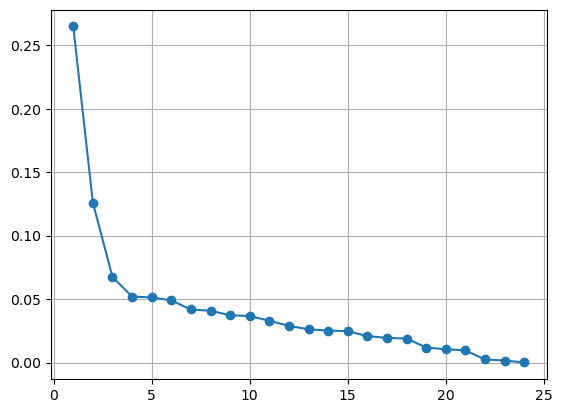

In [122]:
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.grid(True)
plt.show()

In [123]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

In [124]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-2.163546,-1.078123
1,-1.226570,0.691627
2,-1.873811,-0.556139
3,-0.802225,1.429772
4,-1.224475,-2.932363


In [125]:
joblib.dump(pca, "pca.pkl")
joblib.dump(scaler_pca, "scaler_pca.pkl")

['scaler_pca.pkl']

# K MEANS 

In [162]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [163]:
inertia = []
silhouette = []

In [164]:
K = range(2,11)
for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_pca)

    inertia.append(kmeans.inertia_)

    silhouette.append(
        silhouette_score(X_pca, labels)
    )

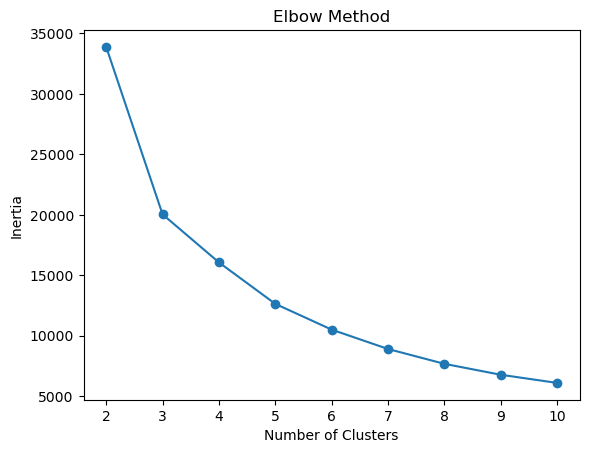

In [165]:
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

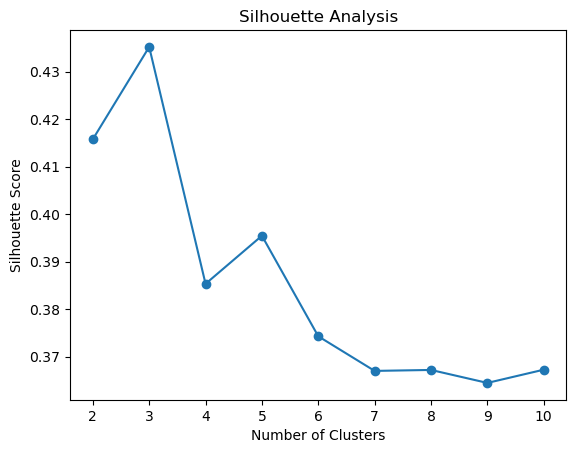

In [166]:
plt.plot(K, silhouette, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [167]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_pca)

In [168]:
df["Cluster"] = clusters

In [169]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,Cluster
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,0
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,1


In [170]:
df["Cluster"].value_counts()

Cluster
1    2444
0    2431
2    2146
Name: count, dtype: int64

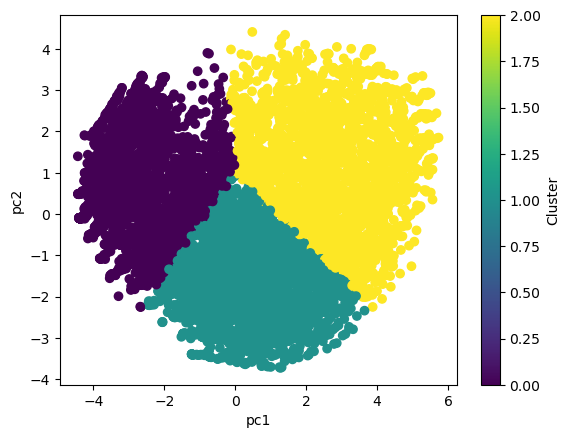

In [171]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("pc1")
plt.ylabel("pc2")
plt.colorbar(label="Cluster")
plt.show()

In [172]:
df["Churn_numeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})
cluster_profile = df.groupby("Cluster")[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "Churn_numeric"
]].mean()

cluster_profile

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,Churn_numeric
Cluster,,,,,
0,25.797614,30.315858,716.998149,25.857332,0.144796
1,17.965221,77.946993,1412.841182,67.399781,0.503273
2,56.545666,89.060974,5060.284669,87.368201,0.128145


In [173]:
pd.crosstab(
    df["Cluster"],
    df["Contract"],
    normalize="index"
) * 100

Contract,Month-to-month,One year,Two year
Cluster,,,
0,48.663102,22.130810,29.206088
1,91.571195,8.183306,0.245499
2,20.130475,34.249767,45.619758


In [174]:
pd.crosstab(
    df["Cluster"],
    df["InternetService"],
    normalize="index"
) * 100

InternetService,DSL,Fiber optic,No
Cluster,,,
0,36.857260,0.946113,62.196627
1,24.713584,75.286416,0.000000
2,42.823858,57.176142,0.000000


In [175]:
pd.crosstab(
    df["Cluster"],
    df["TechSupport"],
    normalize="index"
) * 100

TechSupport,No,Yes
Cluster,,
0,88.235294,11.764706
1,83.633388,16.366612
2,36.719478,63.280522


In [176]:
pd.crosstab(
    df["Cluster"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Cluster,,
0,85.520362,14.479638
1,49.672668,50.327332
2,87.185461,12.814539


In [177]:
df.drop("Churn_numeric", axis=1, inplace=True)

In [178]:
cluster_labels = {
    0: "Budget Loyal Customer",
    1: "At-Risk Customer",
    2: "Loyal High-Value Customer"
}

In [179]:
joblib.dump(kmeans, "kmeans.pkl")

['kmeans.pkl']

In [180]:
joblib.dump(cluster_labels, "cluster_labels.pkl")

['cluster_labels.pkl']